<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Cost Matrix

         A     B     C     D     E
   A   INF    10     8     9     7
   B    10   INF    10     5     6
   C     8    10   INF     8     9
   D     9     5     8   INF     6
   E     7     6     9     6   INF

Optimal Tour
A -> C -> D -> B -> E -> A

Minimum Cost = 34

Path Verification
A -> C = 8
C -> D = 8
D -> B = 5
B -> E = 6
E -> A = 7


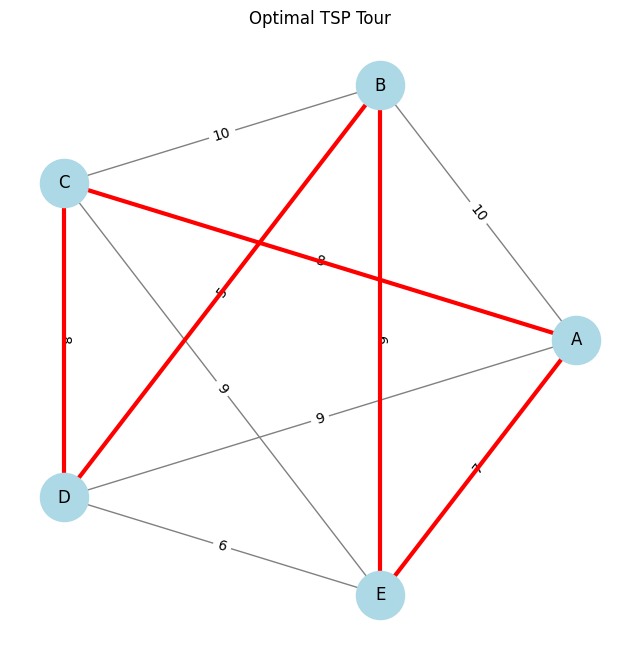

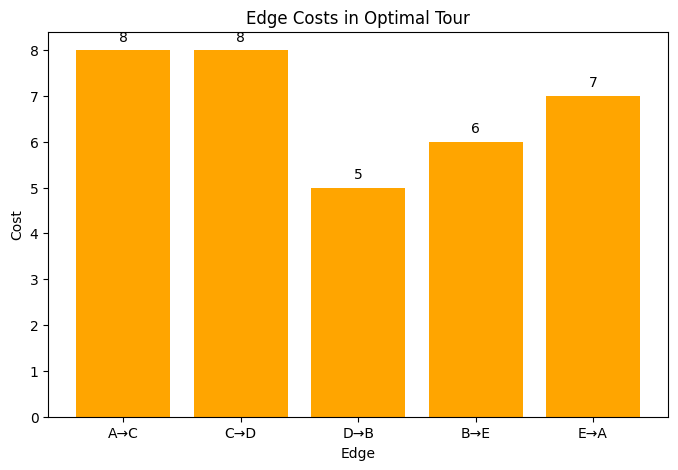

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from itertools import permutations

INF = float('inf')


# -------------------------------------------------
# Matrix Reduction (unchanged)
# -------------------------------------------------
def reduce_matrix(mat):
    """Reduce matrix and return reduction cost"""
    m = [row[:] for row in mat]
    n = len(m)
    cost = 0

    # Row reduction
    for i in range(n):
        row_min = min(m[i])
        if row_min != INF and row_min != 0:
            cost += row_min
            m[i] = [x - row_min if x != INF else INF for x in m[i]]

    # Column reduction
    for j in range(n):
        col_min = min(m[i][j] for i in range(n))
        if col_min != INF and col_min != 0:
            cost += col_min
            for i in range(n):
                if m[i][j] != INF:
                    m[i][j] -= col_min

    return m, cost


# -------------------------------------------------
# Brute Force TSP
# -------------------------------------------------
def tsp_brute_force(cost, n):
    cities = list(range(1, n))

    best_cost = INF
    best_path = None

    for perm in permutations(cities):

        path = [0] + list(perm) + [0]

        total = 0

        for i in range(n):
            total += cost[path[i]][path[i + 1]]

        if total < best_cost:
            best_cost = total
            best_path = path

    return best_path, best_cost


# -------------------------------------------------
# Display Matrix
# -------------------------------------------------
def print_matrix(cost, cities):

    print("\nCost Matrix\n")

    print(f'{"":>4}', end='')

    for c in cities:
        print(f'{c:>6}', end='')

    print()

    for i, row in enumerate(cost):

        print(f'{cities[i]:>4}', end='')

        for val in row:

            if val == INF:
                print(f'{"INF":>6}', end='')
            else:
                print(f'{val:>6}', end='')

        print()


# -------------------------------------------------
# Draw Graph
# -------------------------------------------------
def draw_tsp_graph(cost, cities, best_path):

    G = nx.Graph()

    for city in cities:
        G.add_node(city)

    n = len(cities)

    for i in range(n):
        for j in range(i + 1, n):

            if cost[i][j] != INF:

                G.add_edge(
                    cities[i],
                    cities[j],
                    weight=cost[i][j]
                )

    pos = nx.circular_layout(G)

    plt.figure(figsize=(8, 8))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1200,
        node_color="lightblue"
    )

    nx.draw_networkx_labels(G, pos)

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="gray"
    )

    edge_labels = nx.get_edge_attributes(G, 'weight')

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )

    # Highlight optimal tour
    route = []

    for i in range(len(best_path) - 1):

        u = cities[best_path[i]]
        v = cities[best_path[i + 1]]

        route.append((u, v))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=route,
        edge_color="red",
        width=3
    )

    plt.title("Optimal TSP Tour")
    plt.axis("off")
    plt.show()


# -------------------------------------------------
# Bar Chart
# -------------------------------------------------
def plot_edge_costs(cost, cities, best_path):

    labels = []
    values = []

    for i in range(len(best_path) - 1):

        u = best_path[i]
        v = best_path[i + 1]

        labels.append(f"{cities[u]}→{cities[v]}")
        values.append(cost[u][v])

    plt.figure(figsize=(8, 5))

    plt.bar(labels, values, color="orange")

    plt.ylabel("Cost")
    plt.xlabel("Edge")

    plt.title("Edge Costs in Optimal Tour")

    for i, val in enumerate(values):
        plt.text(i, val + 0.2, str(val), ha='center')

    plt.show()


# =====================================================
# MAIN
# =====================================================

cost = [
    [INF, 10, 8, 9, 7],
    [10, INF, 10, 5, 6],
    [8, 10, INF, 8, 9],
    [9, 5, 8, INF, 6],
    [7, 6, 9, 6, INF]
]

cities = ['A', 'B', 'C', 'D', 'E']

n = len(cities)

print_matrix(cost, cities)

best_path, best_cost = tsp_brute_force(cost, n)

print("\nOptimal Tour")
print(" -> ".join(cities[i] for i in best_path))

print("\nMinimum Cost =", best_cost)

print("\nPath Verification")

for i in range(n):

    u = best_path[i]
    v = best_path[i + 1]

    print(f"{cities[u]} -> {cities[v]} = {cost[u][v]}")

# Graphical Outputs
draw_tsp_graph(cost, cities, best_path)
plot_edge_costs(cost, cities, best_path)